# Online Retail Analytics

## RFM Customer Analysis

### Objective

This notebook performs RFM (Recency, Frequency, Monetary) analysis to identify
customer purchasing behavior and segment customers based on their value.

### Business Goals

- Identify high-value customers
- Measure customer engagement
- Support customer retention strategies
- Prepare data for customer segmentation

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path("../data/processed/cleaned_online_retail.csv")

df = pd.read_csv(DATA_PATH)

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalPrice"] = (
    df["Quantity"] *
    df["Price"]
)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  int64         
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   TotalPrice   779425 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 53.5 MB


In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## Understanding RFM

RFM is a customer analysis technique based on three metrics:

- **Recency** → How recently a customer made a purchase.
- **Frequency** → How often a customer makes purchases.
- **Monetary** → How much money the customer spends.

Customers with low Recency values, high Frequency, and high Monetary values
are generally considered the most valuable customers.

# Step 1 — Create Snapshot Date

## Business Question

What reference date should be used to measure customer recency?

In RFM analysis, Recency is calculated by comparing each customer's most recent
purchase date to a fixed reference date called the **Snapshot Date**.

A common practice is to use one day after the latest transaction in the dataset.

In [6]:
latest_date = df["InvoiceDate"].max()

print(latest_date)

2011-12-09 12:50:00


In [7]:
snapshot_date = latest_date + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [8]:
print(f"Latest Transaction : {latest_date}")
print(f"Snapshot Date      : {snapshot_date}")

Latest Transaction : 2011-12-09 12:50:00
Snapshot Date      : 2011-12-10 12:50:00


# Step 2 — Calculate RFM Metrics

## Business Question

How recently has each customer purchased?
How frequently do they purchase?
How much revenue has each customer generated?

These three metrics form the foundation of the RFM model.

In [9]:
rfm = (
    df.groupby("Customer ID")
      .agg({
          "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
          "Invoice": "nunique",
          "TotalPrice": "sum"
      })
      .reset_index()
)

In [10]:
rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]

In [11]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [12]:
rfm.describe().round(2)

,CustomerID,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00,5878.00
mean,15315.31,201.33,6.29,2955.90
std,1715.57,209.34,13.01,14440.85
min,12346.00,1.00,1.00,2.95
25%,13833.25,26.00,1.00,342.28
50%,15314.50,96.00,3.00,867.74
75%,16797.75,380.00,7.00,2248.30
max,18287.00,739.00,398.00,580987.04


### Business Insight

The RFM table summarizes each customer's purchasing behavior using three key metrics:

- **Recency:** Days since the customer's last purchase.
- **Frequency:** Number of unique orders placed.
- **Monetary:** Total revenue generated by the customer.

These metrics will be used to classify customers into meaningful business segments in the following steps.

# Step 3 — Assign RFM Scores

## Business Question

How can customers be ranked based on their purchasing behavior?

Each customer is assigned a score from **1 to 5** for:

- **Recency**
- **Frequency**
- **Monetary**

A score of **5** represents the best-performing customers, while **1** represents the lowest-performing customers.

In [13]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

In [14]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [15]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [16]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [17]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,12,77556.46,2,5,5
1,12347.0,2,8,4921.53,5,4,5
2,12348.0,75,5,2019.40,3,4,4
3,12349.0,19,4,4428.69,5,3,5
4,12350.0,310,1,334.40,2,1,2


# STEP 4

## Create Overall RFM Score

The three scores are combined into a single RFM Score.

Example:

Recency = 5

Frequency = 4

Monetary = 3

Overall Score = **543**

In [18]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [19]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255
1,12347.0,2,8,4921.53,5,4,5,545
2,12348.0,75,5,2019.40,3,4,4,344
3,12349.0,19,4,4428.69,5,3,5,535
4,12350.0,310,1,334.40,2,1,2,212


In [20]:
rfm["RFM_Score"].value_counts().head(15)

RFM_Score
555    469
111    317
455    248
121    172
211    165
344    164
112    152
444    147
122    135
544    131
355    131
221    122
222    119
233    110
333    106
Name: count, dtype: int64

### Business Insight

The RFM Score combines Recency, Frequency, and Monetary metrics into a single customer profile.

Customers with scores close to **555** are typically the most valuable, while customers with lower scores may require re-engagement or retention campaigns.

This scoring system provides a simple yet powerful way to prioritize customers based on purchasing behavior.

# Step 5 — Customer Segmentation

## Business Question

How can customers be grouped into meaningful business segments?

Using RFM Scores, customers can be categorized into business-friendly
segments such as Champions, Loyal Customers, At Risk, and Lost Customers.

These segments help businesses design personalized marketing strategies,
improve customer retention, and maximize customer lifetime value.

In [22]:
def customer_segment(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 4:
        return "Loyal Customers"

    elif row["R_Score"] >= 4:
        return "Recent Customers"

    elif row["F_Score"] >= 4:
        return "Frequent Customers"

    elif row["M_Score"] >= 4:
        return "Big Spenders"

    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "At Risk"

    else:
        return "Others"

In [23]:
rfm["Segment"] = rfm.apply(customer_segment, axis=1)

In [24]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,12,77556.46,2,5,5,255,Frequent Customers
1,12347.0,2,8,4921.53,5,4,5,545,Champions
2,12348.0,75,5,2019.40,3,4,4,344,Loyal Customers
3,12349.0,19,4,4428.69,5,3,5,535,Recent Customers
4,12350.0,310,1,334.40,2,1,2,212,At Risk


In [25]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Customers"]

segment_counts

,Segment,Customers
0,At Risk,1460
1,Champions,1297
2,Others,900
3,Recent Customers,882
4,Loyal Customers,701
5,Frequent Customers,353
6,Big Spenders,285


# Customer Segment Distribution

## Business Question

How are customers distributed across the different RFM segments?

Understanding the size of each customer segment helps businesses prioritize
marketing campaigns, customer retention efforts, and growth strategies.

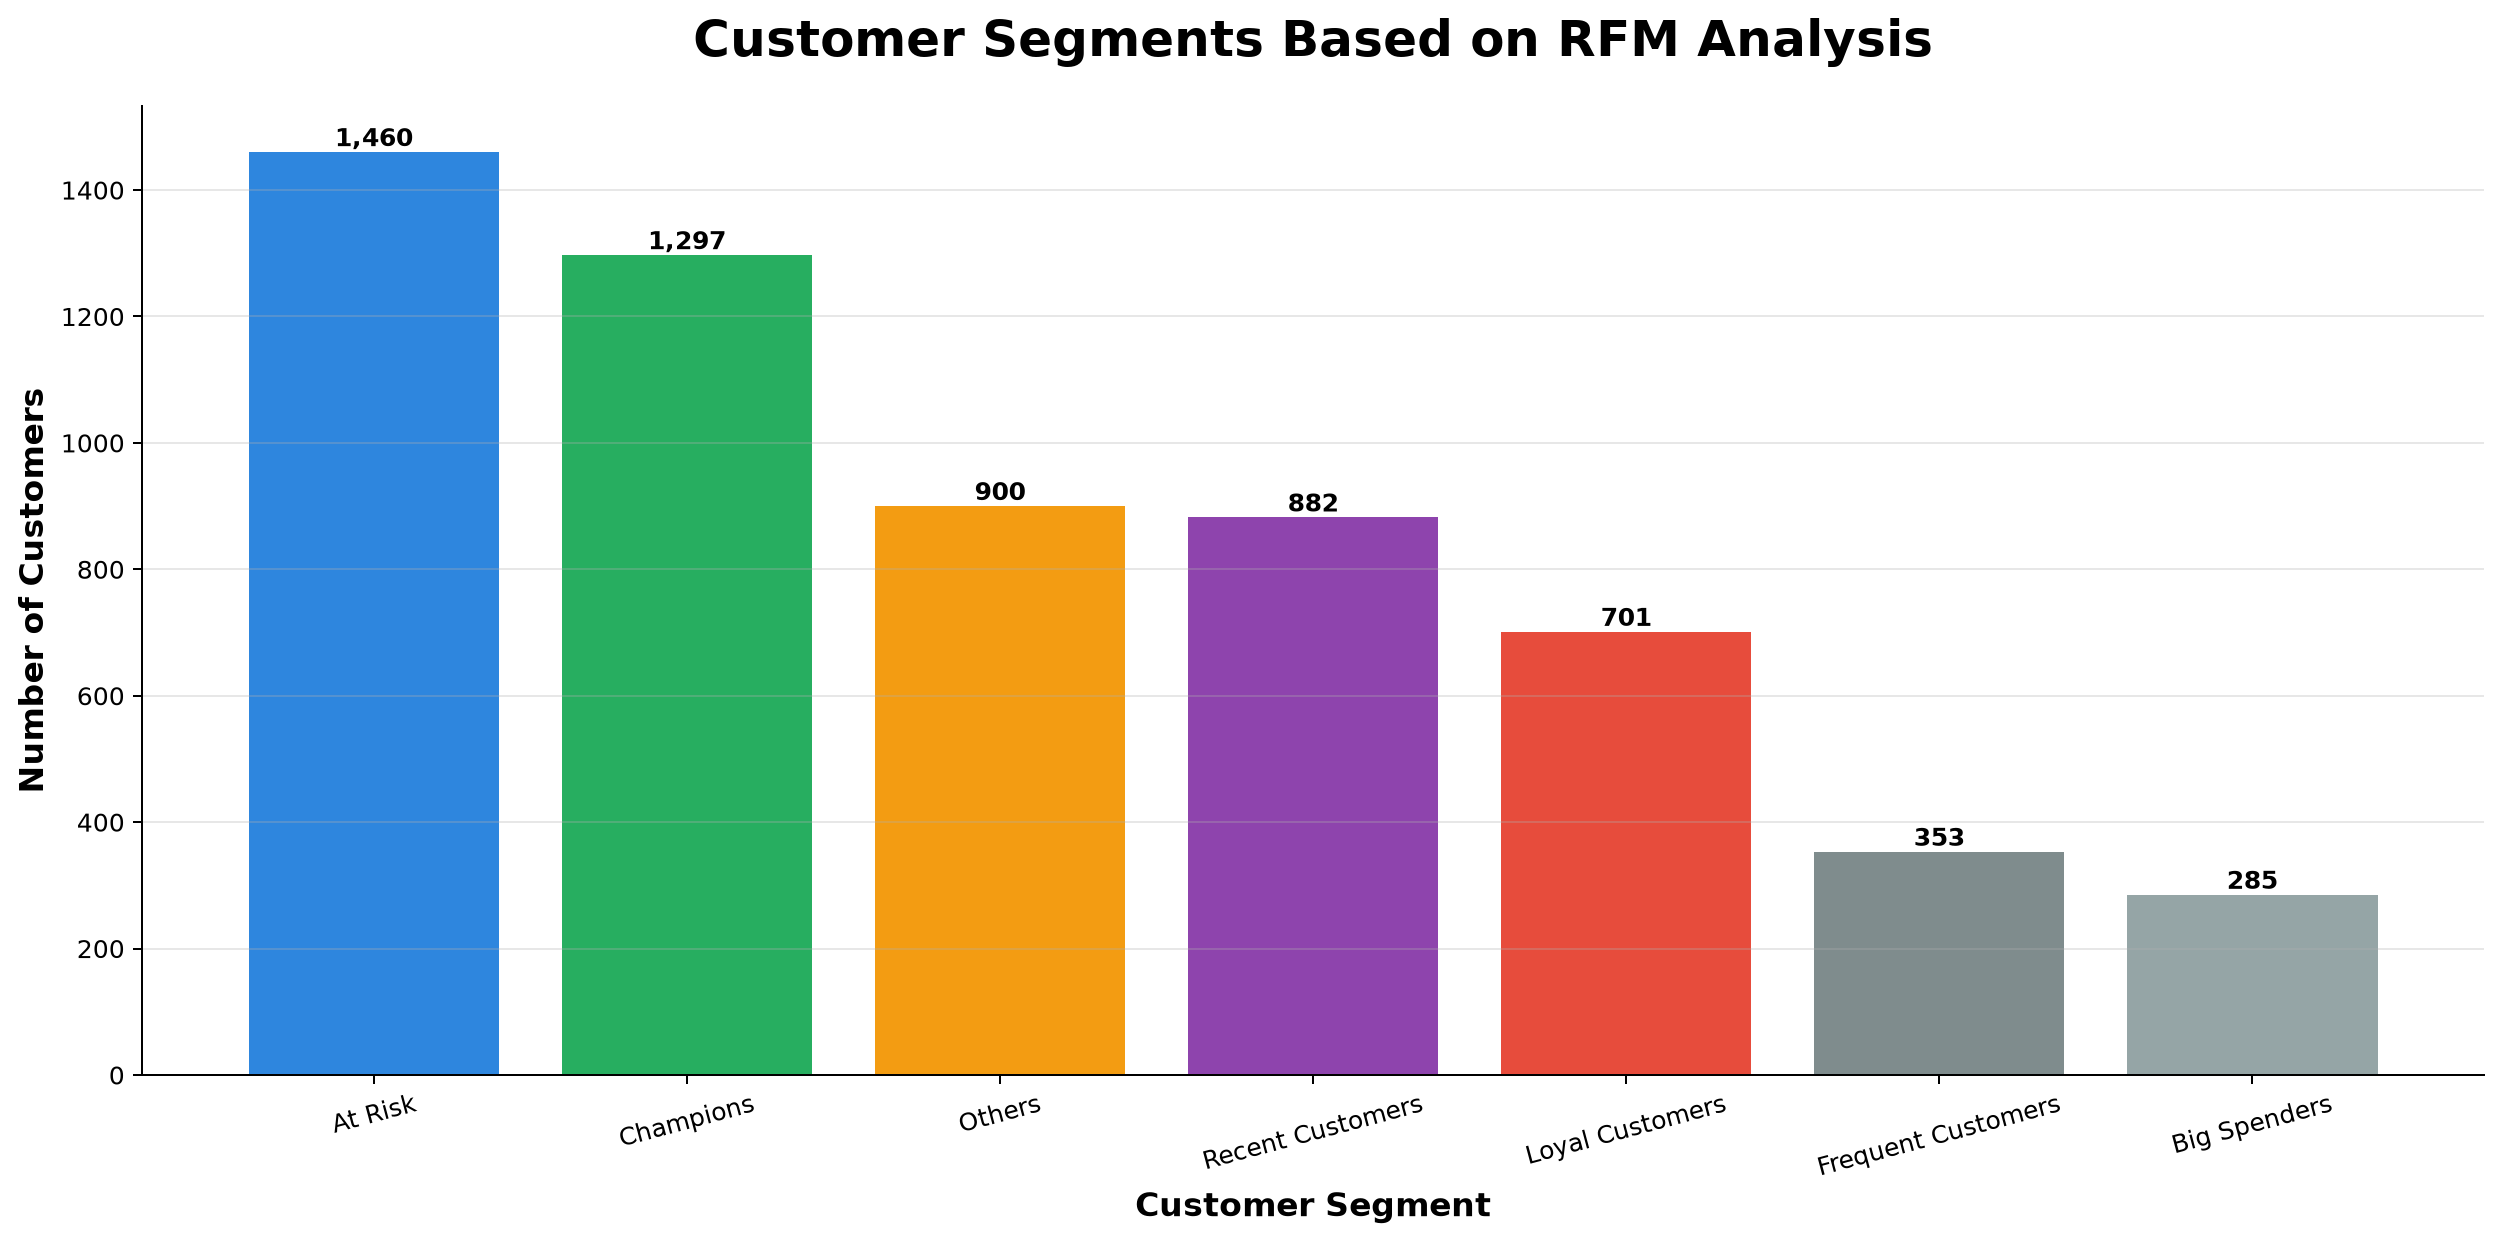

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,7), dpi=180)

colors = [
    "#2E86DE",
    "#27AE60",
    "#F39C12",
    "#8E44AD",
    "#E74C3C",
    "#7F8C8D",
    "#95A5A6"
]

bars = ax.bar(
    segment_counts["Segment"],
    segment_counts["Customers"],
    color=colors[:len(segment_counts)]
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Customer Segments Based on RFM Analysis",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Customer Segment", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Customers", fontsize=13, fontweight="bold")

plt.xticks(rotation=15)

ax.grid(axis="y", alpha=0.30)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

## Business Insight

The RFM segmentation reveals distinct groups of customers with different purchasing behaviors.

- **Champions** are the most valuable customers and should receive exclusive rewards and loyalty benefits.
- **Loyal Customers** consistently purchase and are ideal candidates for upselling and cross-selling.
- **Recent Customers** are new or recently active customers who should be nurtured to encourage repeat purchases.
- **Frequent Customers** buy often but may have lower spending, making them suitable for targeted promotions.
- **Big Spenders** generate high revenue and should receive premium customer experiences.
- **At Risk** customers have not purchased recently and should be targeted with re-engagement campaigns.

# Step 6 — Segment Performance Analysis

## Business Question

How does each customer segment perform?

This analysis compares customer segments based on:

- Number of customers
- Total revenue
- Average revenue
- Average purchase frequency
- Average recency

These metrics help identify which customer groups contribute the most value to the business.

In [27]:
segment_summary = (
    rfm.groupby("Segment")
       .agg(
           Customers=("CustomerID", "count"),
           Avg_Recency=("Recency", "mean"),
           Avg_Frequency=("Frequency", "mean"),
           Avg_Monetary=("Monetary", "mean"),
           Total_Revenue=("Monetary", "sum")
       )
       .round(2)
       .sort_values("Total_Revenue", ascending=False)
)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
Champions,1297,19.96,17.11,9143.86,11859591.50
Loyal Customers,701,84.37,7.74,2648.60,1856667.02
Frequent Customers,353,344.21,7.57,3089.79,1090694.27
Recent Customers,882,26.51,2.29,988.19,871585.66
Big Spenders,285,281.23,2.76,2534.96,722463.46
Others,900,222.76,2.31,554.29,498862.91
At Risk,1460,460.87,1.24,325.30,474939.44


In [28]:
segment_summary.style.format({
    "Avg_Recency": "{:.0f} days",
    "Avg_Frequency": "{:.1f}",
    "Avg_Monetary": "${:,.2f}",
    "Total_Revenue": "${:,.2f}"
})

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
Champions,1297,20 days,17.1,"$9,143.86","$11,859,591.50"
Loyal Customers,701,84 days,7.7,"$2,648.60","$1,856,667.02"
Frequent Customers,353,344 days,7.6,"$3,089.79","$1,090,694.27"
Recent Customers,882,27 days,2.3,$988.19,"$871,585.66"
Big Spenders,285,281 days,2.8,"$2,534.96","$722,463.46"
Others,900,223 days,2.3,$554.29,"$498,862.91"
At Risk,1460,461 days,1.2,$325.30,"$474,939.44"


# Segment Performance by Revenue

## Business Question

Which customer segments generate the most revenue?

This visualization compares the total revenue generated by each customer segment,
helping prioritize retention and marketing strategies.

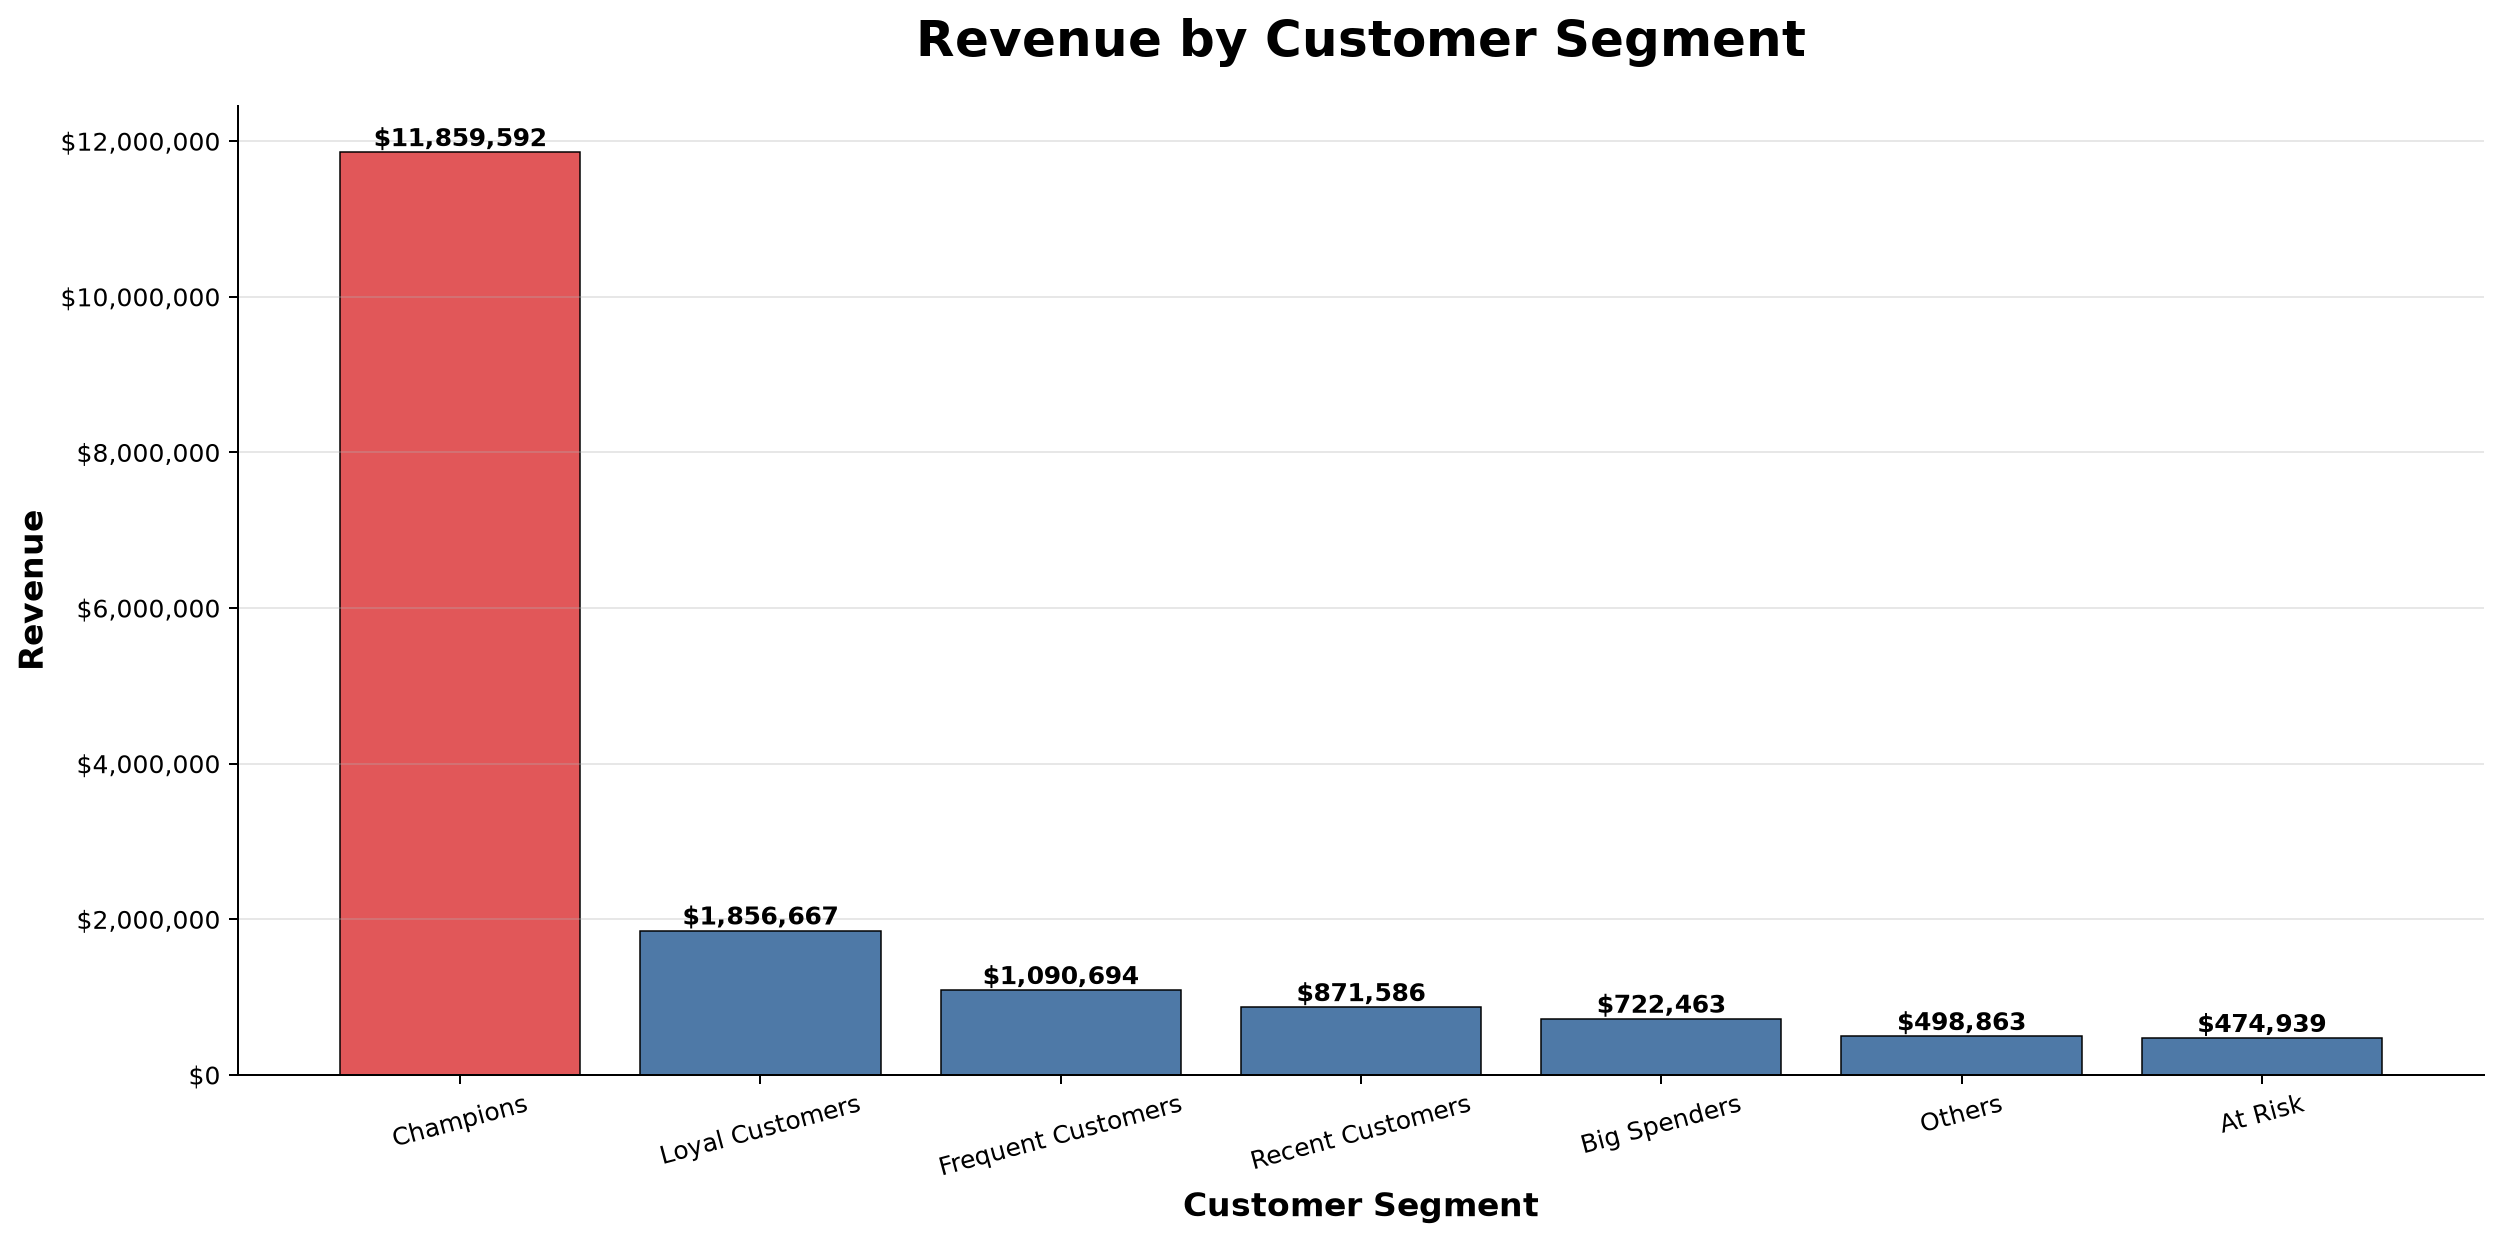

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plot_data = (
    segment_summary
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7), dpi=180)

colors = ["#4E79A7"] * len(plot_data)

champion_idx = plot_data.index[
    plot_data["Segment"] == "Champions"
]

if len(champion_idx) > 0:
    colors[champion_idx[0]] = "#E15759"

bars = ax.bar(
    plot_data["Segment"],
    plot_data["Total_Revenue"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

for bar in bars:

    value = bar.get_height()

    ax.text(
        bar.get_x()+bar.get_width()/2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.set_title(
    "Revenue by Customer Segment",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Customer Segment",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Revenue",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=15)

ax.grid(
    axis="y",
    alpha=0.30
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

# Executive Summary

## Key Findings

- Champions generate the highest revenue and should receive premium loyalty benefits.
- Loyal Customers represent a stable revenue source and offer strong upselling opportunities.
- At Risk customers require immediate re-engagement campaigns to reduce churn.
- Recent Customers should be nurtured into long-term loyal buyers.
- Segment-based marketing is more effective than applying the same strategy to all customers.

## Business Recommendation

The company should adopt personalized marketing strategies for each customer segment rather than using a single campaign for the entire customer base. This approach is expected to improve customer retention, increase lifetime value, and maximize overall revenue.